<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Aptos;text-align:center;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Actuarial Agents: Responsible AI Agent Teams for Actuarial Risk Prediction</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><b>Author: Bart Custers</b></div>

<div style="padding:16px;color:darkblue;margin:0;font-size:18px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:white;overflow:hidden"><i>MSc Thesis Artificial Intelligence, School of Computer Science, University of Hull</i></div>

<a id="top"></a>
# <div style="padding:20px;color:white;margin:0;font-size:24px;font-family:Aptos;text-align:left;display:fill;border-radius:5px;background-color:#00008B;overflow:hidden"><b>Evaluation: Notebook for deriving output statistics.</b></div>

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = "C:/Users/bart_/Documents/Thesis/results/Workflow_run_stats.xlsx"

df_original = pd.read_excel(file_path, sheet_name="original")
df_test = pd.read_excel(file_path, sheet_name="test")

# Publication style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300
})

# Inspect columns
print(df_original.columns)
df_original.head()

Index(['RunID', 'Timestamp', 'LLM_backend', 'Dataset', 'Workflow_succes',
       'Workflow_decision', 'Iterations', 'Adaptive_dataprep_succes',
       'Model_choice', 'Adaptive_model_code_succes', 'Belief_assessment',
       'TCAV_assessment', 'Fairness_assessment', 'RMSE', 'MAE',
       'Poisson_deviance', 'P(Workflow=OK)', 'Comment', 'Error_detected',
       'Decision_dataprep_review', 'Decision_model_review', 'Sparsity_zero',
       'Sparsity_numeric', 'row_change', 'col_change', 'missingness',
       'target_shift', 'avg_psi', 'corr_shift', 'severity_score'],
      dtype='object')


,RunID,Timestamp,LLM_backend,Dataset,Workflow_succes,Workflow_decision,Iterations,Adaptive_dataprep_succes,Model_choice,Adaptive_model_code_succes,...,Decision_model_review,Sparsity_zero,Sparsity_numeric,row_change,col_change,missingness,target_shift,avg_psi,corr_shift,severity_score
0,1,20260205_180357,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,20260205_181231,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,20260205_183138,Llama 2 7B,Original,1,APPROVE,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,20260205_195843,Llama 2 7B,Original,1,CONSULT_ACTUARY,1.0,1,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,20260205_201858,Llama 2 7B,Original,1,CONSULT_ACTUARY,1.0,0,GLM,0,...,NaN,0.086244,0.129366,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Consistency tests on fixed dataset**

### **1. Task Success Rate per LLM**

    LLM_backend  Success_rate
0    Llama 2 7B      0.800000
1  Llama 3.1 8B      0.909091
2    Qwen2.5 7B      0.800000


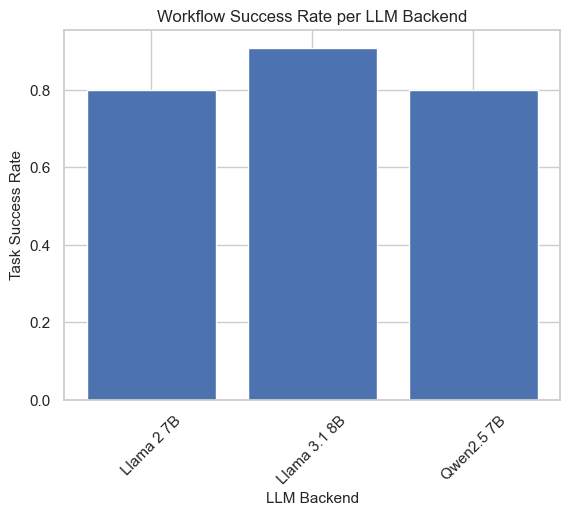

In [58]:
# Ensure Workflow_success is numeric (0/1 or True/False)
df_original["Workflow_succes"] = df_original["Workflow_succes"].astype(int)

# Compute success rate per LLM backend
success_rate = (
    df_original.groupby("LLM_backend")["Workflow_succes"]
    .mean()
    .reset_index()
)

success_rate.rename(columns={"Workflow_succes": "Success_rate"}, inplace=True)

print(success_rate)

# Plot success rate
plt.figure()
plt.bar(success_rate["LLM_backend"], success_rate["Success_rate"])
plt.xlabel("LLM Backend")
plt.ylabel("Task Success Rate")
plt.title("Workflow Success Rate per LLM Backend")
plt.xticks(rotation=45)
plt.show()

### **2. Workflow outcome per LLM**

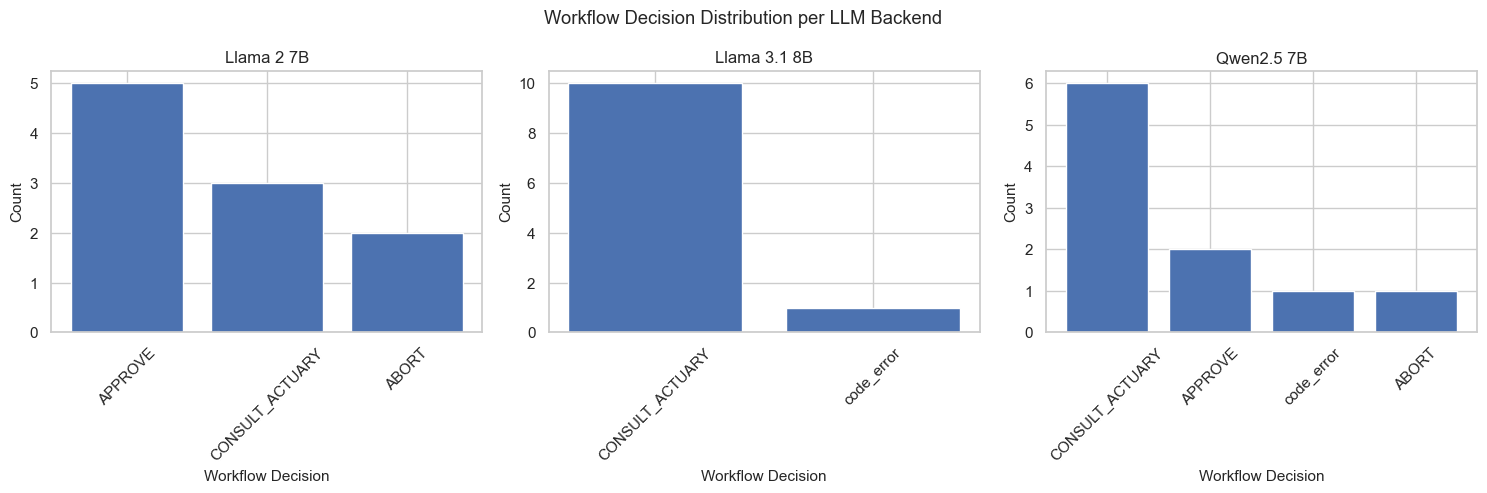

In [59]:
llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5))

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    counts = subset["Workflow_decision"].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(backend)
    axes[i].set_xlabel("Workflow Decision")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Workflow Decision Distribution per LLM Backend")
plt.tight_layout()
plt.show()

### **3. Model choice per LLM**

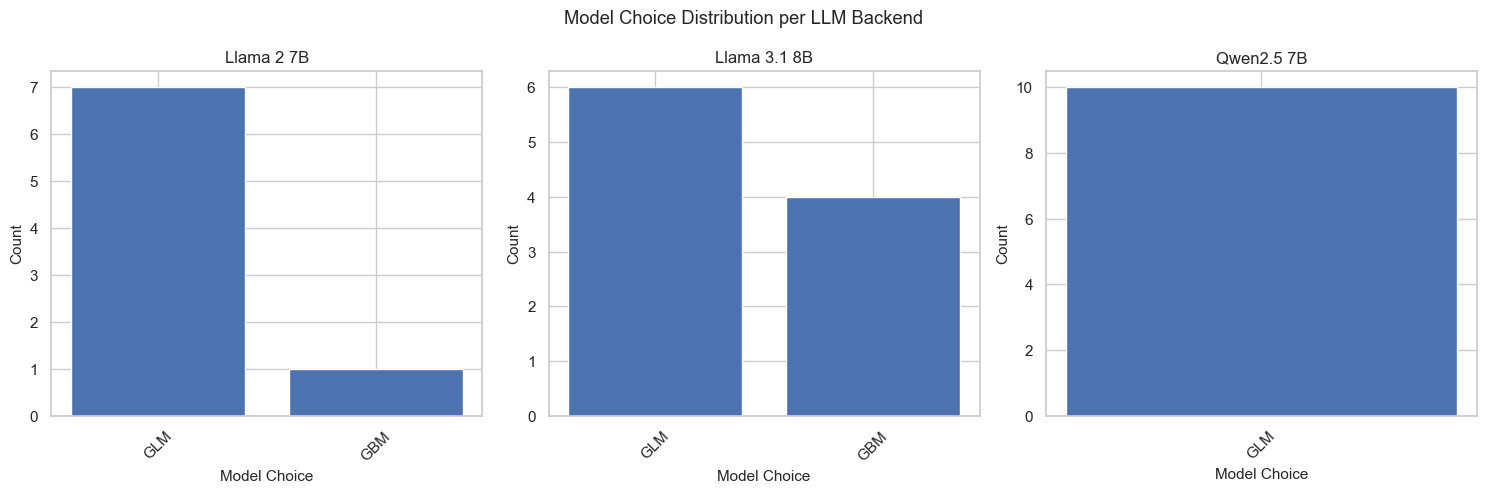

In [60]:
fig, axes = plt.subplots(1, len(llms), figsize=(15,5))

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    counts = subset["Model_choice"].value_counts()
    
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(backend)
    axes[i].set_xlabel("Model Choice")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle("Model Choice Distribution per LLM Backend")
plt.tight_layout()
plt.show()

### **4. Model RMSE per LLM**

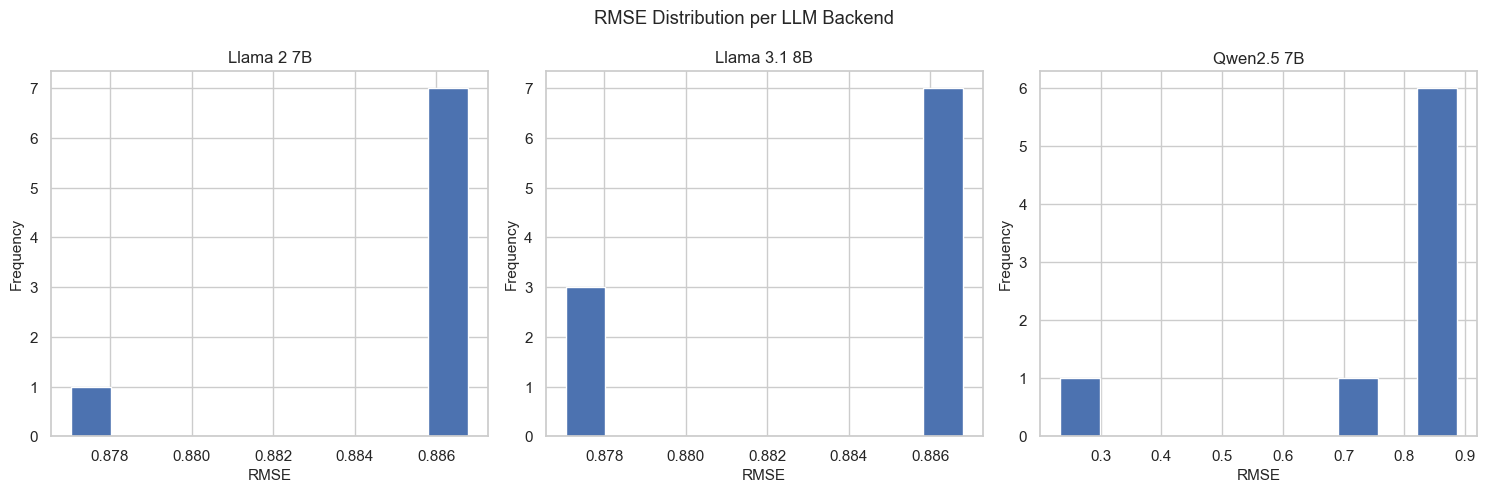

In [61]:
fig, axes = plt.subplots(1, len(llms), figsize=(15,5))

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    axes[i].hist(subset["RMSE"], bins=10)
    axes[i].set_title(backend)
    axes[i].set_xlabel("RMSE")
    axes[i].set_ylabel("Frequency")

fig.suptitle("RMSE Distribution per LLM Backend")
plt.tight_layout()
plt.show()

### **5. Code generation success**

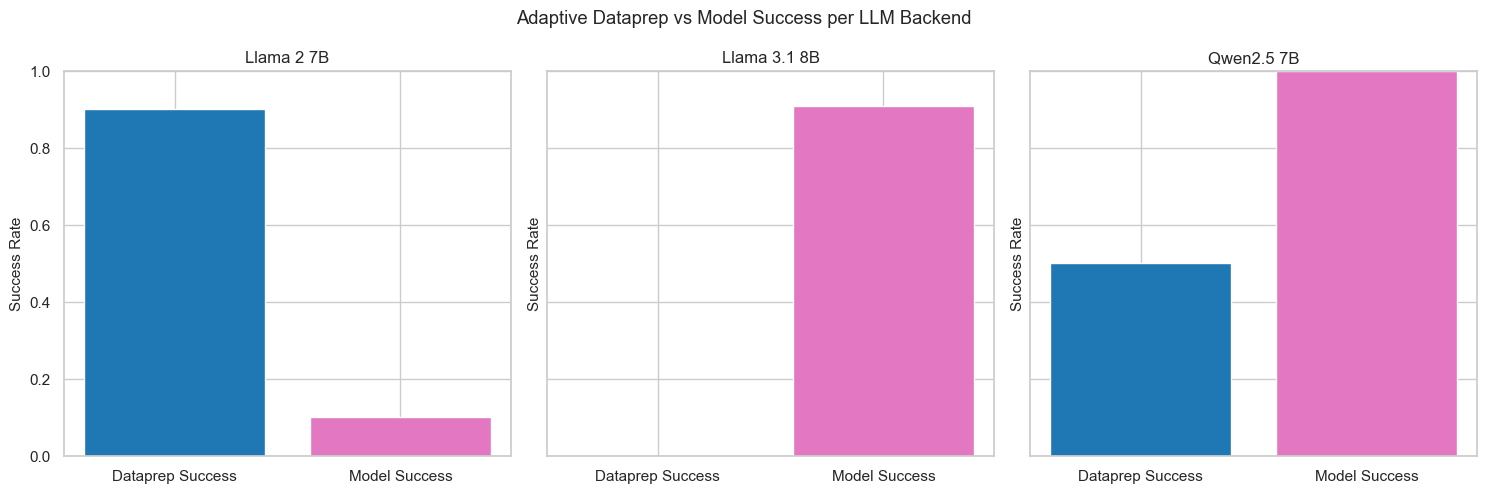

In [62]:
# Ensure success columns are numeric (0/1)
df_original["Adaptive_dataprep_succes"] = pd.to_numeric(df_original["Adaptive_dataprep_succes"], errors="coerce")
df_original["Adaptive_model_code_succes"] = pd.to_numeric(df_original["Adaptive_model_code_succes"], errors="coerce")

llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5), sharey=True)

# If only one LLM exists, make axes iterable
if len(llms) == 1:
    axes = [axes]

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend]
    
    # Compute success rates
    dataprep_rate = subset["Adaptive_dataprep_succes"].mean()
    model_rate = subset["Adaptive_model_code_succes"].mean()
    
    axes[i].bar(
        "Dataprep Success",
        dataprep_rate,
        color="tab:blue"
    )
    
    axes[i].bar(
        "Model Success",
        model_rate,
        color="tab:pink"
    )
    
    axes[i].set_title(backend)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Success Rate")

fig.suptitle("Adaptive Dataprep vs Model Success per LLM Backend")
plt.tight_layout()
plt.show()

### **6. Number of iterations per run, per LLM backend**

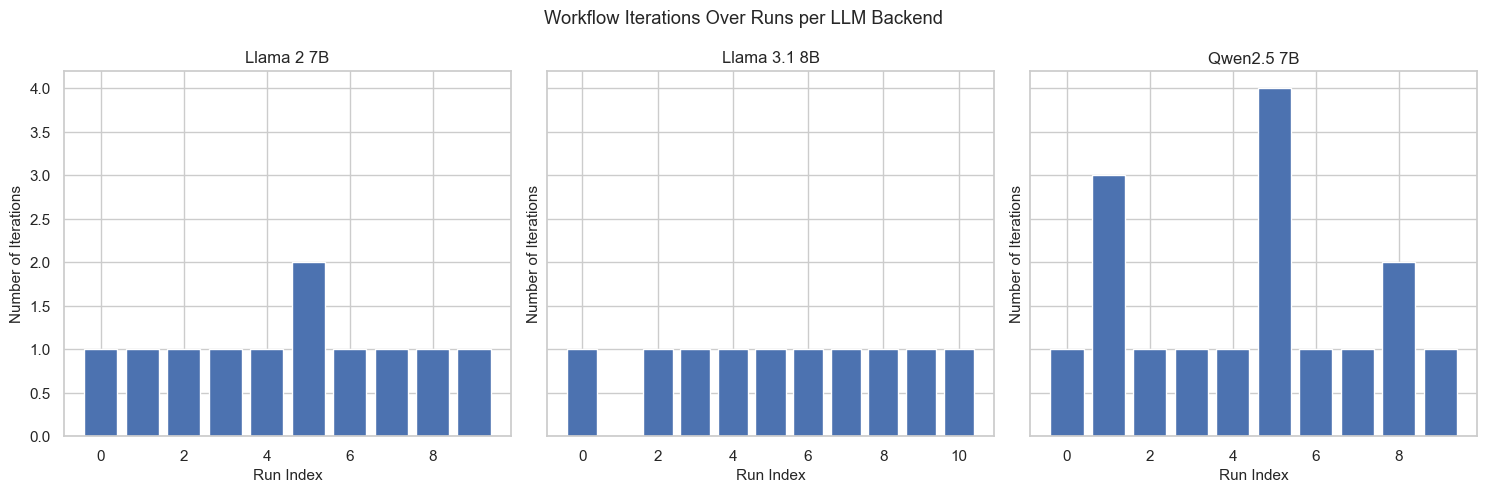

In [63]:
df_original["Iterations"] = pd.to_numeric(df_original["Iterations"], errors="coerce")

llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5), sharey=True)

# If only one LLM exists
if len(llms) == 1:
    axes = [axes]

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend].reset_index(drop=True)
    
    axes[i].bar(subset.index, subset["Iterations"])
    axes[i].set_title(backend)
    axes[i].set_xlabel("Run Index")
    axes[i].set_ylabel("Number of Iterations")

fig.suptitle("Workflow Iterations Over Runs per LLM Backend")

plt.tight_layout()
plt.show()

### **7. BN uncertainty outcome**

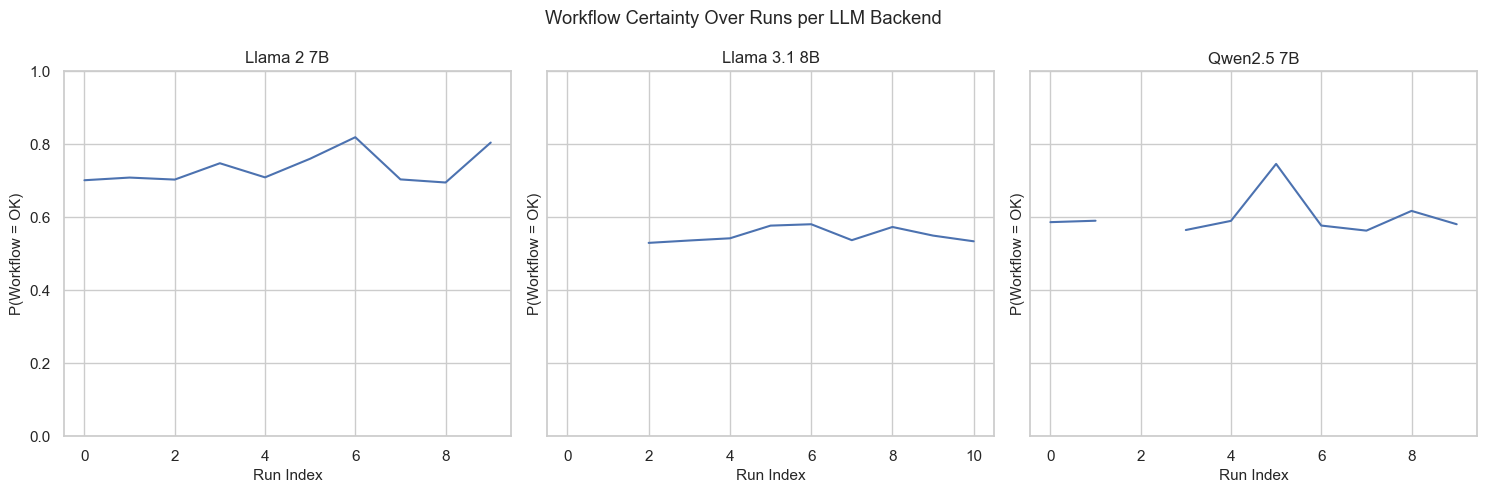

In [64]:
# Ensure numeric (handles NaN safely)
df_original["P(Workflow=OK)"] = pd.to_numeric(df_original["P(Workflow=OK)"], errors="coerce")

llms = df_original["LLM_backend"].unique()

fig, axes = plt.subplots(1, len(llms), figsize=(15,5), sharey=True)

# Handle single LLM case
if len(llms) == 1:
    axes = [axes]

for i, backend in enumerate(llms):
    subset = df_original[df_original["LLM_backend"] == backend].reset_index(drop=True)
    
    axes[i].plot(subset.index, subset["P(Workflow=OK)"])
    axes[i].set_title(backend)
    axes[i].set_xlabel("Run Index")
    axes[i].set_ylabel("P(Workflow = OK)")
    axes[i].set_ylim(0, 1)

fig.suptitle("Workflow Certainty Over Runs per LLM Backend")

plt.tight_layout()
plt.show()

## **Adaptability tests**

In [65]:
# Inspect columns
print(df_test.columns)
df_test.head()

Index(['RunID', 'Timestamp', 'LLM_backend', 'Dataset', 'Workflow_succes',
       'Workflow_decision', 'Iterations', 'Adaptive_dataprep_succes',
       'Model_choice', 'Adaptive_model_code_succes', 'Belief_assessment',
       'TCAV_assessment', 'Fairness_assessment', 'RMSE', 'MAE',
       'Poisson_deviance', 'P(Workflow=OK)', 'Comment', 'Error_detected',
       'Decision_dataprep_review', 'Decision_model_review', 'Sparsity',
       'Sparsity_numeric', 'row_change', 'col_change', 'missingness',
       'target_shift', 'avg_psi', 'corr_shift', 'severity_score',
       'severity_score2'],
      dtype='object')


,RunID,Timestamp,LLM_backend,Dataset,Workflow_succes,Workflow_decision,Iterations,Adaptive_dataprep_succes,Model_choice,Adaptive_model_code_succes,...,Sparsity,Sparsity_numeric,row_change,col_change,missingness,target_shift,avg_psi,corr_shift,severity_score,severity_score2
0,41,20260219_151045,Llama 2 7B,Test_T10,1,APPROVE,1,1,GLM,0,...,0.086244,0.129366,0.0,0.000000,0.0,0.0,0.000642,0.006600,0.007242,0.007242
1,58,20260219_154412,Llama 3.1 8B,Test_T10,1,CONSULT_ACTUARY,2,1,GLM,1,...,0.086244,0.129366,0.0,0.000000,0.0,0.0,0.000642,0.006600,0.007242,0.007242
2,70,20260223_141334,Qwen2.5 7B,Test_T5,1,CONSULT_ACTUARY,2,0,GLM,1,...,0.086342,0.135681,0.0,0.083333,0.0,0.0,0.000000,0.000000,0.083333,0.000000
3,40,20260219_095012,Llama 2 7B,Test_T9,1,APPROVE,1,1,GLM,1,...,0.086244,0.129366,0.0,0.000000,0.0,0.0,0.002204,0.007121,0.009326,0.009326
4,57,20260219_101149,Llama 3.1 8B,Test_T9,1,CONSULT_ACTUARY,2,1,GLM,1,...,0.086244,0.129366,0.0,0.000000,0.0,0.0,0.002204,0.007121,0.009326,0.009326


### **8. ...**

Overall performance, can also compare this to the original runs in a table

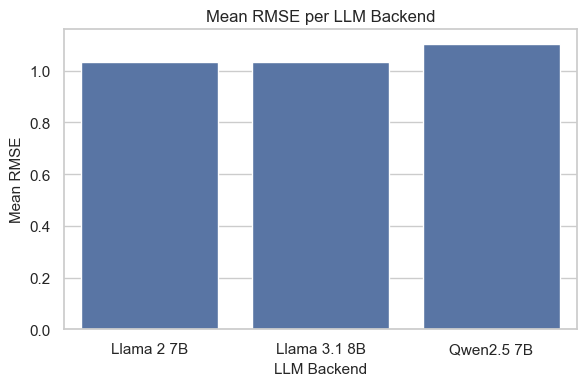

In [66]:
performance_summary = (
    df_test.groupby("LLM_backend")
      .agg({
          "RMSE": "mean",
          "MAE": "mean",
          "Poisson_deviance": "mean"
      })
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=performance_summary,
    x="LLM_backend",
    y="RMSE"
)

plt.title("Mean RMSE per LLM Backend")
plt.xlabel("LLM Backend")
plt.ylabel("Mean RMSE")
plt.tight_layout()
plt.savefig("fig_rmse_backend.png")
plt.show()

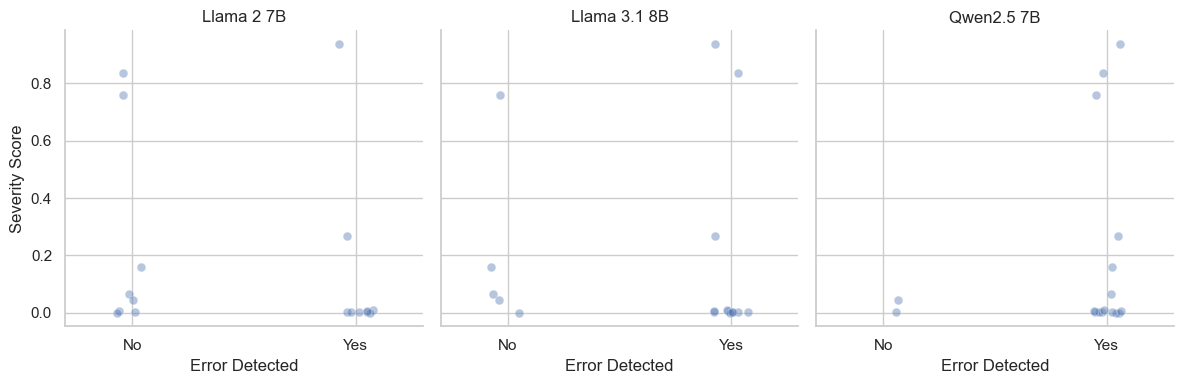

In [ ]:
import numpy as np

sns.set_theme(style="whitegrid")

# Create jittered version of Error_detected
df_test["Error_jitter"] = (
    df_test["Error_detected"] +
    np.random.uniform(-0.08, 0.08, size=len(df_test))
)

g = sns.FacetGrid(
    df_test,
    col="LLM_backend",
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Error_jitter",
    y="severity_score2",
    alpha=0.4,
    s=40
)

g.set_axis_labels("Error Detected", "Severity Score")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlim(-0.3, 1.3)

plt.tight_layout()
plt.savefig("fig_severity_scatter_per_backend.png", bbox_inches="tight")
plt.show()

When ERROR DETECTED:

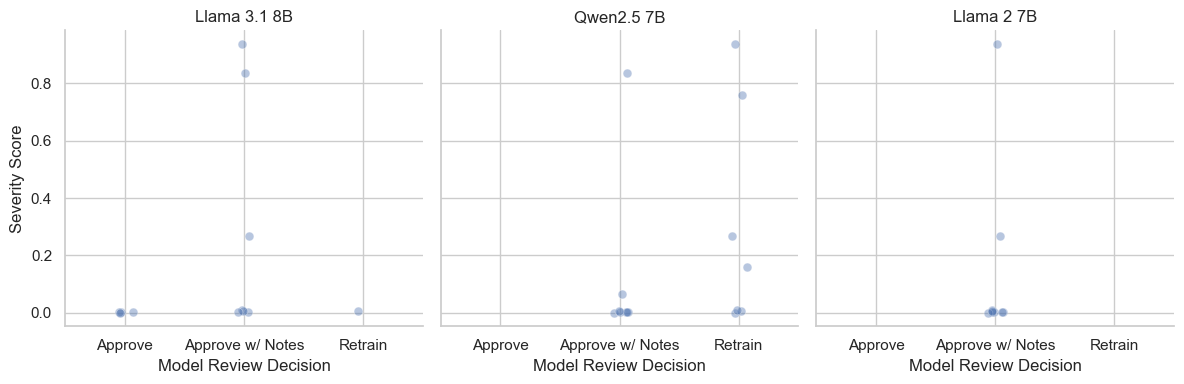

In [84]:
sns.set_theme(style="whitegrid")

# Filter to detected errors
df_detected = df_test[df_test["Error_detected"] == 1].copy()

# Ensure ordered categories (important!)
decision_order = [
    "APPROVE",
    "APPROVE_WITH_NOTES",
    "RETRAIN"
]

df_detected["Decision_model_review"] = pd.Categorical(
    df_detected["Decision_model_review"],
    categories=decision_order,
    ordered=True
)

# Add horizontal jitter
df_detected["Decision_numeric"] = df_detected["Decision_model_review"].cat.codes
df_detected["Decision_jitter"] = (
    df_detected["Decision_numeric"] +
    np.random.uniform(-0.08, 0.08, size=len(df_detected))
)

# Faceted scatter
g = sns.FacetGrid(
    df_detected,
    col="LLM_backend",
    height=4,
    aspect=1,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Decision_jitter",
    y="severity_score2",
    alpha=0.4,
    s=40
)

g.set_axis_labels("Model Review Decision", "Severity Score")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([
        "Approve",
        "Approve w/ Notes",
        "Retrain"
    ])
    ax.set_xlim(-0.5, 2.5)

plt.tight_layout()
plt.savefig("fig_severity_model_review_scatter.png", bbox_inches="tight")
plt.show()

Optional, appendix

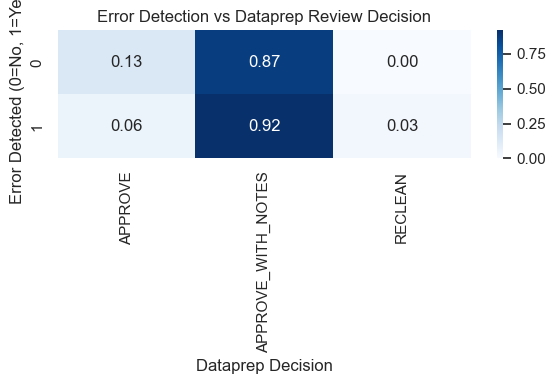

In [69]:
# Crosstab (row-normalized)
dataprep_ct = pd.crosstab(
    df_test["Error_detected"],
    df_test["Decision_dataprep_review"],
    normalize="index"
)

plt.figure(figsize=(6,4))
sns.heatmap(
    dataprep_ct,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Error Detection vs Dataprep Review Decision")
plt.xlabel("Dataprep Decision")
plt.ylabel("Error Detected (0=No, 1=Yes)")
plt.tight_layout()
plt.savefig("fig_error_vs_dataprep.png")
plt.show()

Optional, appendix

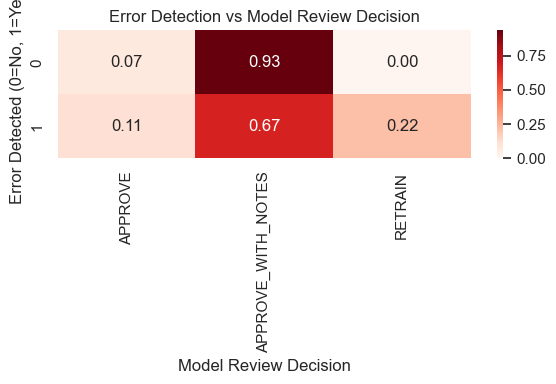

In [70]:
model_ct = pd.crosstab(
    df_test["Error_detected"],
    df_test["Decision_model_review"],
    normalize="index"
)

plt.figure(figsize=(6,4))
sns.heatmap(
    model_ct,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Error Detection vs Model Review Decision")
plt.xlabel("Model Review Decision")
plt.ylabel("Error Detected (0=No, 1=Yes)")
plt.tight_layout()
plt.savefig("fig_error_vs_model_review.png")
plt.show()

Optional:

<Figure size 700x500 with 0 Axes>

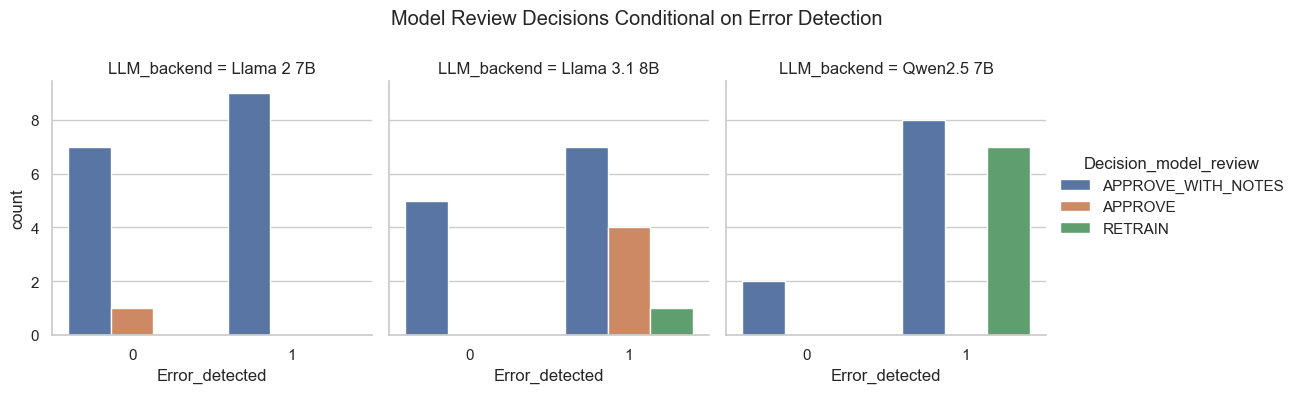

In [71]:
plt.figure(figsize=(7,5))

sns.catplot(
    data=df_test,
    x="Error_detected",
    hue="Decision_model_review",
    col="LLM_backend",
    kind="count",
    height=4,
    aspect=0.9
)

plt.subplots_adjust(top=0.8)
plt.suptitle("Model Review Decisions Conditional on Error Detection")
plt.savefig("fig_backend_error_modelreview.png")
plt.show()

Compare uncertainty scores.

Compare this also to the original runs (in a table?)

C:\Users\bart_\AppData\Local\Temp\ipykernel_7704\3300247049.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



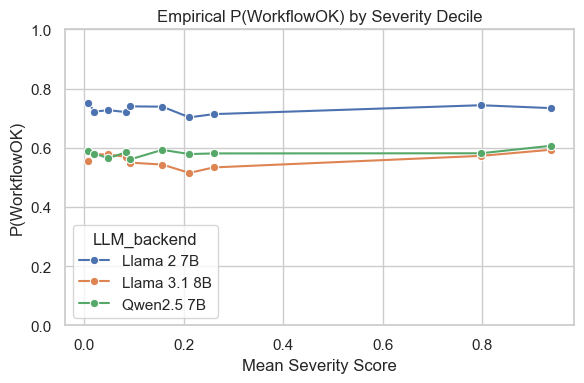

In [ ]:
# Create severity deciles
df_test["severity_bin"] = pd.qcut(
    df_test["severity_score"],
    q=10,
    duplicates="drop"
)

summary = (
    df_test
    .groupby(["severity_bin", "LLM_backend"])
    .agg(
        mean_severity=("severity_score", "mean"),
        prob_workflowok=("P(Workflow=OK)", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=summary,
    x="mean_severity",
    y="prob_workflowok",
    hue="LLM_backend",
    marker="o"
)

plt.title("Empirical P(WorkflowOK) by Severity Decile")
plt.xlabel("Mean Severity Score")
plt.ylabel("P(WorkflowOK)")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("fig_workflowok_probability_binned.png", bbox_inches="tight")
plt.show()

Plot distributions of the explanation assessments and compare to Original runs (only for Qwen)

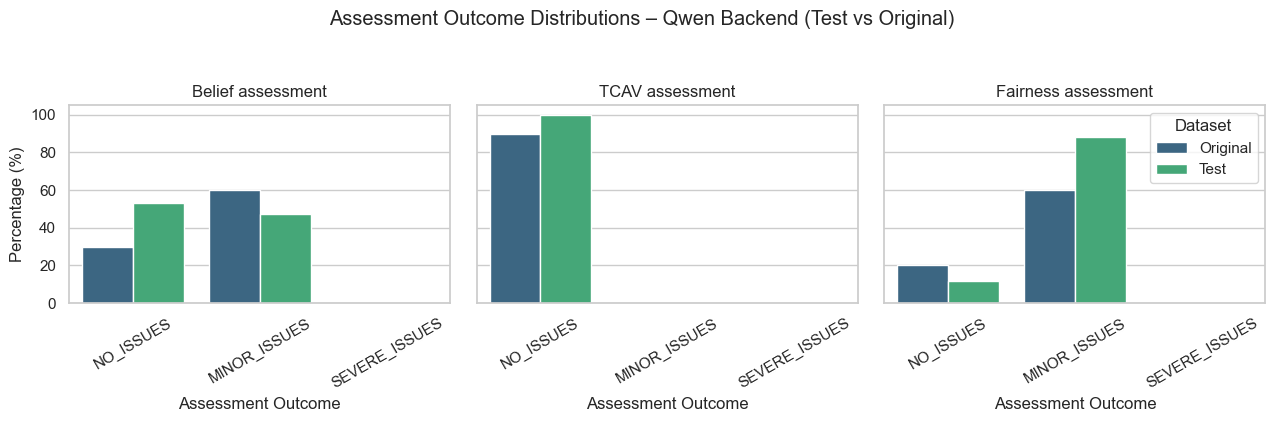

In [ ]:
assessment_categories = ["NO_ISSUES", "MINOR_ISSUES", "SEVERE_ISSUES"]
assessment_cols = ["Belief_assessment", "TCAV_assessment", "Fairness_assessment"]

# Filter backend if needed
df_test_qwen = df_test[df_test["LLM_backend"] == "Qwen2.5 7B"].copy()
df_original_qwen = df_original[df_original["LLM_backend"] == "Qwen2.5 7B"].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# Dataset sizes (for normalization)
n_test = len(df_test_qwen)
n_original = len(df_original_qwen)

for ax, col in zip(axes, assessment_cols):

    # Count distributions
    test_counts = (
        df_test_qwen[col]
        .dropna()
        .value_counts()
        .reindex(assessment_categories, fill_value=0)
    )

    original_counts = (
        df_original_qwen[col]
        .dropna()
        .value_counts()
        .reindex(assessment_categories, fill_value=0)
    )

    # Convert to percentages
    test_pct = 100 * test_counts / n_test if n_test > 0 else test_counts * 0
    original_pct = 100 * original_counts / n_original if n_original > 0 else original_counts * 0

    # Build plot dataframe (Original first, then Test)
    plot_df = pd.DataFrame({
        "Outcome": list(assessment_categories) * 2,
        "Dataset": ["Original"] * len(assessment_categories) +
                ["Test"] * len(assessment_categories),
        "Percentage": list(original_pct.values) + list(test_pct.values)
    })

    sns.barplot(
        data=plot_df,
        x="Outcome",
        y="Percentage",
        hue="Dataset",
        hue_order=["Original", "Test"],
        palette="viridis",
        ax=ax
    )

    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Assessment Outcome")
    ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis='x', rotation=30)

    if ax != axes[-1]:
        ax.legend_.remove()

plt.suptitle("Assessment Outcome Distributions – Qwen Backend (Test vs Original)", y=1.05)
plt.tight_layout()

plt.savefig("fig_qwen_assessment_distributions_comparison.png", bbox_inches="tight")
plt.show()

Estimation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Features to use
FEATURES = [
    "sparsity",
    "row_change",
    "col_change",
    "missingness",
    "target_shift",
    "avg_psi",
    "corr_shift"
]

TARGET = "Error_detected"

# Clean dataset copy
df_model = df_test.copy()

# Convert percentage-like columns if stored as strings
for col in FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Drop missing values
df_model = df_model.dropna(subset=FEATURES + [TARGET, "LLM_backend"])

# Container for results
importance_results = {}

# Train model per backend
for backend in df_model["LLM_backend"].unique():

    df_backend = df_model[df_model["LLM_backend"] == backend]

    if len(df_backend) < 10:
        continue  # avoid unstable models

    X = df_backend[FEATURES]
    y = df_backend[TARGET]

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Logistic regression (L2 regularized)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, y)

    # Feature importance = absolute standardized coefficient
    importance = pd.Series(
        np.abs(model.coef_[0]),
        index=FEATURES
    ).sort_values(ascending=False)

    importance_results[backend] = importance

# Convert to dataframe
importance_df = pd.DataFrame(importance_results)

print("\n=== Feature Importance by Backend ===")
print(importance_df)


=== Feature Importance by Backend ===
              Llama 2 7B  Llama 3.1 8B  Qwen2.5 7B
Sparsity        0.130472      0.112435    0.133689
avg_psi         0.746746      0.905364    0.830039
col_change      0.068458      0.387244    0.240239
corr_shift      0.902811      0.640238    0.284472
missingness     0.379901      0.402592    0.071397
row_change      0.601717      0.245080    0.005854
target_shift    0.555859      0.654373    0.204224


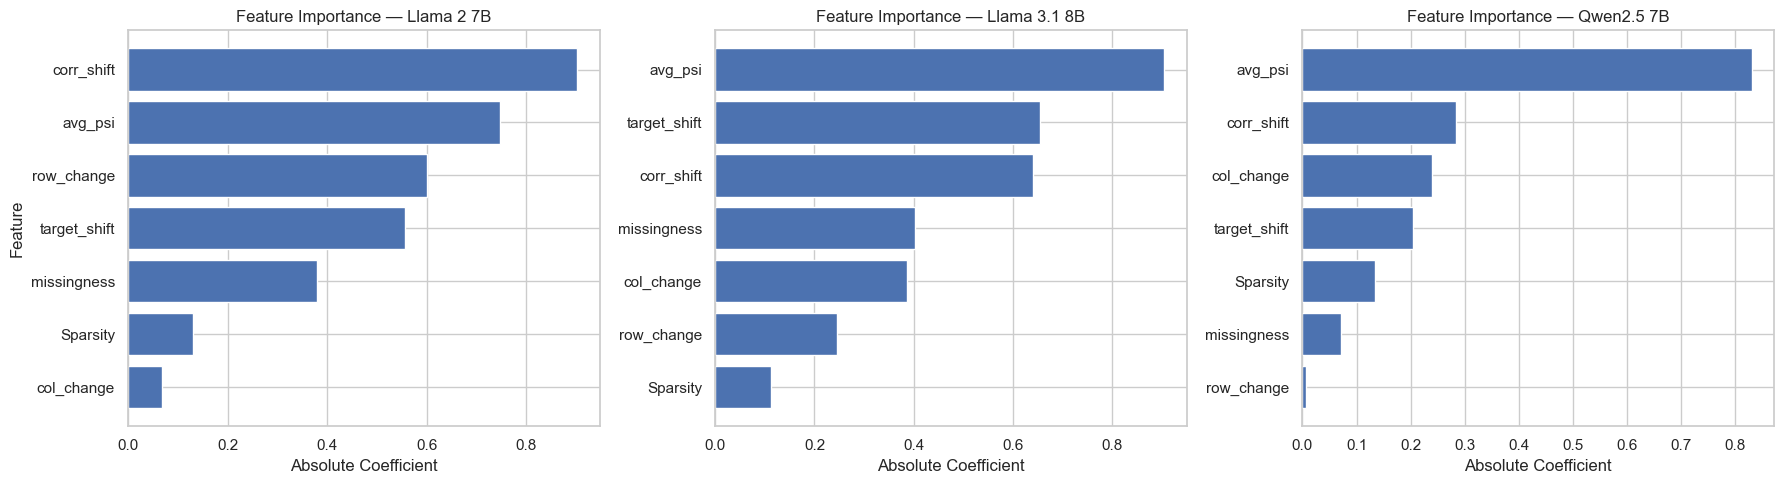

In [83]:
# Safety check
if importance_df is None or importance_df.empty:
    print("importance_df is empty. Train models first.")
else:
    # Select up to 3 backends
    backend_list = importance_df.columns[:3]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Ensure axes is iterable
    axes = axes.flatten()

    for i in range(3):
        ax = axes[i]

        if i < len(backend_list):
            backend = backend_list[i]

            # Sort importance (ascending for horizontal bar plot)
            backend_importance = importance_df[backend].abs().sort_values()

            ax.barh(backend_importance.index, backend_importance.values)

            ax.set_title(f"Feature Importance — {backend}")
            ax.set_xlabel("Absolute Coefficient")

            if i == 0:
                ax.set_ylabel("Feature")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()